# 🏥 Predicción de Ausentismo en Citas Médicas con Machine Learning (LightGBM)
## Modelo de Clasificación para Priorizar la Gestión de Riesgos y Optimizar Recursos

**Objetivo del Proyecto:** Desarrollar un modelo de Machine Learning para predecir la **inasistencia** a citas médicas respecto a una base de datos de un centro médico ubicado en la ciudad de quillota. El objetivo principal es optimizar la gestión de recursos, enfocando los esfuerzos de confirmación y recordatorio en los pacientes con alta probabilidad de ausentismo a partir de la métrica Recall (priorizando la **detección**) a partir de una clasificación binaria.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
import funciones as fn
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.base import clone
import warnings

## Introducción

### a. Contexto
La inasistencia a citas médicas es un problema operativo y económico significativo. Genera pérdidas de ingresos, subutilización de la capacidad clínica y prolonga los tiempos de espera para otros pacientes. En el centro médico donde trabajo los ingresos se pueden dividir en 2 grandes áreas: los controles médicos y kinesiología. El alto volumen de pacientes a controles de ambas áreas requiere de un esfuerzo importante a la hora de la confirmación de las citas, por lo que, el 5% promedio de inasistencia entre el año 2024 y lo que va de 2025 hace necesario evaluar la posibilidad de entrenar un modelo que permita orientar de forma más eficiente los recursos para disminuir al mínimo las inasistencias.

### b. Objetivo del modelo
El objetivo específico del modelo de machine learning es la **Clasificación binaria**, prediciendo si un paciente **Asistirá (Clase 0)** o **Inasistirá (Clase 1)**, buscando **maximizar la métrica Recall para la Clase 1 (Inasistencia)**, esperando que el modelo capte  el mayor número posible de verdaderos inasistentes.

### c. Alcance del proyecto
Este notebook cubre las fases del proyecto desde la recolección inicial del `dataset.csv`, la exploración y el preprocesamiento de datos, la evaluación comparativa de modelos, la optimización (Grid Search), la selección del umbral de mayor recall y, finalmente, la interpretación de los factores de riesgo  y la robustez por segmentos.

---

## Importación de archivo y exploración inicial

### a. Fuente de los datos
Los datos provienen de un conjunto de datos anonimizado de citas médicas del periodo Enero 2024 - Agosto 2025, proporcionado por la plataforma medilink al centro médico. El archivo utilizado tiene por nombre `dataset.csv`.

### b. Distribución de los datos
El conjunto de datos presenta un severo desbalance de clases:

- **Asiste (Clase 0):** ≈64.7% (≈6,338 casos)
- **Inasiste (Clase 1):** ≈35.3% (≈3,451 casos)

Este desbalance confirma la necesidad de usar técnicas de balanceo (SMOTE) y priorizar métricas como **Recall** y **F1-Score**.


In [2]:
#Cargar el dataset
df = pd.read_csv('dataset.csv')

# Mostrar las primeras filas y la información del dataset para verificación
print("Primeras filas del dataset:")
print(df.head())
print("\nInformación del dataset:")
df.info() 

Primeras filas del dataset:
   # Cita      Estado Cita  Fecha Cita Mes Cita  Año Cita Hora Inicio Cita  \
0  134945  Cambio de fecha  2024-01-01    Enero      2024         12:15:00   
1  136417         Atendido  2024-01-01    Enero      2024         15:00:00   
2  136431         Atendido  2024-01-01    Enero      2024         18:00:00   
3  132696         Atendido  2024-01-02    Enero      2024         17:00:00   
4  133669         Atendido  2024-01-02    Enero      2024         10:00:00   

  Hora Fin Cita                 Comentario Cita Sillón (Recurso)  \
0      12:30:00  urgente hr antes de esta fecha         Sillon 1   
1      16:00:00                             NaN         Sillon 1   
2      19:00:00                             NaN         Sillon 1   
3      17:20:00                         17 TEOC         Sillon 1   
4      10:15:00               v lic  01-01-2024         Sillon 1   

  Tipo de atención  ...  Convenio Paciente  Convenio Tratamiento  \
0         Consulta  ...   

In [3]:
print(df['Estado Cita'].unique())
print(df['Especialidad Profesional'].unique())

['Cambio de fecha' 'Atendido' 'Anulado' 'Anulado por pcte. via email'
 'No asiste' 'No confirmado' 'Confirmado por teléfono' 'En sala de espera'
 'Notificado via email' 'Contactado por chat de WhatsApp'
 'Confirmado por email' 'Anulado vía validación'
 'Anulado por sesiones en conflicto' 'Agenda Online' 'Atendiéndose']
['Traumatología' 'Psicología' 'Fisiatría' 'Terapeuta Ocupacional'
 'Radiología' 'General' 'Podología' 'Piso Pélvico (kinesiología)'
 'Kinesiología' 'Cardiología' 'Deportología' 'Nutricionista' 'Geriatría'
 'Neurología' 'Resonancia Magnética' 'Acupuntura' 'Urologia' 'Otorrino'
 'Cirugía plástica' 'Ginecología']


## Preprocesamiento y Preparación de Datos

Esta sección se enfoca en transformar los datos brutos a un formato apto para el entrenamiento:

1.  **Feature Engineering:** Se crearon variables clave como la **inasistencia** (variable target), `dias_espera`, `grupo_etario` y `turno_cita`.
2.  **Codificación y Escalamiento:** Se utilizó `ColumnTransformer` para aplicar One-Hot Encoding (OHE) a las variables categóricas (`convenio`, `especialidad`, etc.) y `StandardScaler` a las variables numéricas.
3.  **Manejo del Desbalance:** Se aplicó **SMOTE** al conjunto de entrenamiento (`X_train`) para generar muestras sintéticas de la clase minoritaria (Inasistencia) y mejorar la capacidad de detección del modelo.

In [4]:
df_limpio = fn.preprocesamiento_datos(df)

📊 Filtro IQR aplicado a 'dias_espera'. Límite Superior: 22 días.
   Filas eliminadas por IQR: 4605 (8.29%)

⚠️ ALERTA DE DATOS NULOS (Filas a eliminar en el Dropna final):
   Filas a eliminar por NA: 1985
   Columnas responsables de los NAs (por conteo):
convenio    1985
Name: NA Count, dtype: int64

✅ Preprocesamiento completado. El DataFrame final 'df_final' (limpio y preprocesado) está listo.

Columnas finales y sus tipos de datos (Listas para el modelo):
<class 'pandas.core.frame.DataFrame'>
Index: 48942 entries, 0 to 55531
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   especialidad  48942 non-null  object
 1   grupo_etario  48942 non-null  object
 2   convenio      48942 non-null  object
 3   dias_espera   48942 non-null  int64 
 4   turno_cita    48942 non-null  object
 5   inasistencia  48942 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 2.6+ MB

Conteo de clases en el DataFrame con inasistenc

In [5]:
# 1. Separar features (X) y target (y)
X = df_limpio.drop('inasistencia', axis=1) 
y = df_limpio['inasistencia']

# 2. División de datos de entrenamiento y prueba (train_test_split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- División de Datos Completada ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Balanceo inicial en y_train (Clase 1 / Clase 0):\n{y_train.value_counts(normalize=True)}")

# 3. Aplicar Transformaciones (Normalización, OHE y SMOTE)
X_train_smote, X_test_ohe, y_train_smote = fn.aplicar_transformaciones_finales(
    X_train, X_test, y_train
)

print("\n--- Transformación y Balanceo Completado ---")
print(f"Número de Features finales: {X_train_smote.shape[1]}")
print(f"X_train (Post-SMOTE y OHE): {X_train_smote.shape[0]} filas")
print(f"X_test (Post-OHE/Escalado): {X_test_ohe.shape[0]} filas")
print("\nBalanceo de y_train después de SMOTE (Debe ser 50/50):")
print(y_train_smote.value_counts())

--- División de Datos Completada ---
X_train shape: (39153, 5)
X_test shape: (9789, 5)
Balanceo inicial en y_train (Clase 1 / Clase 0):
inasistencia
0    0.64746
1    0.35254
Name: proportion, dtype: float64

--- Transformación y Balanceo Completado ---
Número de Features finales: 42
X_train (Post-SMOTE y OHE): 50700 filas
X_test (Post-OHE/Escalado): 9789 filas

Balanceo de y_train después de SMOTE (Debe ser 50/50):
inasistencia
0    25350
1    25350
Name: count, dtype: int64


## Modelado, Selección y Optimización (LGBM)

Se evaluaron varios modelos de clasificación binaria (Regresión Logística, Random Forest, LGBM, etc.). El modelo **LightGBM (LGBM)** demostró el mejor rendimiento en la métrica **ROC-AUC** y **F1-Score**, siendo seleccionado como el modelo final y optimizado mediante *Grid Search* para afinar sus hiperparámetros.

In [6]:
# 1. Definir el Diccionario de Modelos ---
modelos_base = {
    'Regresión Logística': LogisticRegression(random_state=42, solver='liblinear'),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest (RF)': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5),
    'LightGBM (LGBM)': LGBMClassifier(random_state=42, verbose=-1, n_estimators=100, max_depth=5, learning_rate=0.1),
    'Naive Bayes (GNB)': GaussianNB()
}

resultados_modelos = {}

# 2. Bucle de Entrenamiento y Evaluación ---
print("--- Iniciando Entrenamiento y Evaluación de Modelos Base ---")

for nombre, modelo in modelos_base.items():
    print(f"\nEntrenando: {nombre}...")
    
    modelo_entrenado = fn.entrenar_modelo(X_train_smote, y_train_smote, modelo)
    
    metricas = fn.evaluar_modelo_general(modelo_entrenado, X_test_ohe, y_test)
    
    resultados_modelos[nombre] = metricas
    
    print(f"  ✅ {nombre} - AUC_ROC: {metricas['AUC_ROC']:.4f}")

df_resultados = pd.DataFrame(resultados_modelos).T.sort_values(by='AUC_ROC', ascending=False)

--- Iniciando Entrenamiento y Evaluación de Modelos Base ---

Entrenando: Regresión Logística...
  ✅ Regresión Logística - AUC_ROC: 0.6729

Entrenando: Árbol de Decisión...
  ✅ Árbol de Decisión - AUC_ROC: 0.6811

Entrenando: Random Forest (RF)...
  ✅ Random Forest (RF) - AUC_ROC: 0.6824

Entrenando: LightGBM (LGBM)...
  ✅ LightGBM (LGBM) - AUC_ROC: 0.6916

Entrenando: Naive Bayes (GNB)...
  ✅ Naive Bayes (GNB) - AUC_ROC: 0.6271


In [7]:
# Optimización de Hiperparámetros (LightGBM)

# 1. Seleccionar el mejor modelo base
modelo_a_optimizar = LGBMClassifier(random_state=42, verbose=-1)

# 2. Definir la grilla de hiperparámetros
# NOTA: Esta grilla es un ejemplo. Puedes ajustarla.
param_grid_lgbm = {
    'n_estimators': [100, 200],              # Número de árboles
    'learning_rate': [0.05, 0.1, 0.15],      # Tasa de aprendizaje
    'max_depth': [5, 8, 12],                 # Profundidad máxima
    'num_leaves': [31, 60]                   # Número máximo de hojas
}

# 3. Ejecutar la optimización
modelo_lgbm_optimo, mejores_params = fn.optimizar_modelo_con_grid_search(
    modelo_a_optimizar,
    X_train_smote,
    y_train_smote,
    param_grid_lgbm
)

print("\n--- 4. Re-evaluación del Modelo Óptimo ---")

# Re-evaluar el modelo optimizado en el set de prueba (X_test_ohe)
metricas_optimizadas = fn.evaluar_modelo_general(modelo_lgbm_optimo, X_test_ohe, y_test)

df_optimo = pd.Series(metricas_optimizadas).to_frame(name='LightGBM (Óptimo)').T

print("✅ LightGBM Optimizado vs. Resultados Base:")
print(df_optimo.to_markdown(floatfmt=".4f"))

# Guardar los parámetros para el reporte final
print(f"\nLos parámetros finales son: {mejores_params}")

Iniciando Grid Search para LGBMClassifier...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

--- Resultados del Grid Search ---
Mejor score (roc_auc): 0.7175
Mejores hiperparámetros: {'learning_rate': 0.15, 'max_depth': 12, 'n_estimators': 100, 'num_leaves': 60}

--- 4. Re-evaluación del Modelo Óptimo ---
✅ LightGBM Optimizado vs. Resultados Base:
|                   |   AUC_ROC |   Precision (1) |   Recall (1) |   F1-Score (1) |
|:------------------|----------:|----------------:|-------------:|---------------:|
| LightGBM (Óptimo) |    0.6762 |          0.4852 |       0.5917 |         0.5332 |

Los parámetros finales son: {'learning_rate': 0.15, 'max_depth': 12, 'n_estimators': 100, 'num_leaves': 60}


## Búsqueda y Definición del Umbral Operacional

Dada la naturaleza del problema (priorizar la detección de ausencias), el objetivo principal es maximizar el **Recall** (sensibilidad).

La curva **Precisión vs. Recall** nos guía a elegir un umbral que equilibre la detección con un costo operativo tolerable. Se seleccionó el umbral de **0.36** que maximiza el F1-Score y proporciona un **Recall del 84%** para la inasistencia.

* **Recall (Detección): 0.84** (Alto Valor de Negocio)
* **Precisión (Costo de Alerta): 0.43** (Costo Operacional Aceptable)


--- Análisis de Puntos Clave en el Trade-off ---
1. Umbral de MÁXIMO F1 (Verdad Matemática): 0.3566 (F1: 0.5657)
2. Umbral de ALTO RECALL (Decisión de Centro médico): 0.3600


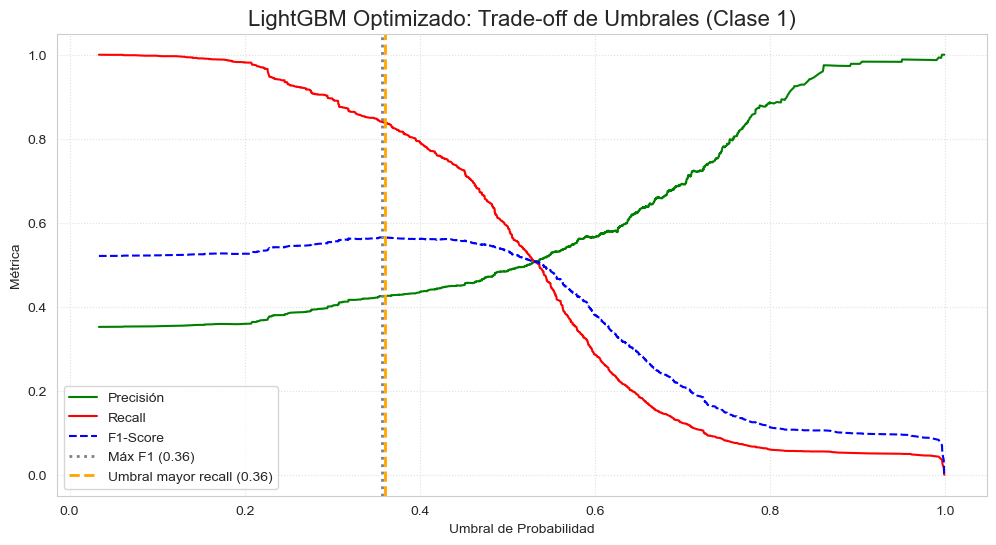


--- Matriz de Confusión: Umbral NEUTRAL (0.5000) (Rendimiento Base) ---
|                 |   Pred No Ausente |   Pred Ausente |
|:----------------|------------------:|---------------:|
| Real No Ausente |              4171 |           2167 |
| Real Ausente    |              1409 |           2042 |
   Métricas: Precisión=0.4852, Recall=0.5917, F1=0.5332

--- Matriz de Confusión: Umbral ALTO RECALL (0.3600) (Estrategia de Detección) ---
|                 |   Pred No Ausente |   Pred Ausente |
|:----------------|------------------:|---------------:|
| Real No Ausente |              2442 |           3896 |
| Real Ausente    |               559 |           2892 |
   Métricas: Precisión=0.4260, Recall=0.8380, F1=0.5649

✅ Umbral de Final Adoptado: 0.3600
   Justificación: El Umbral de Máximo F1 (0.3566) coincide con la necesidad de Alto Recall, validando la elección de 0.3600 para priorizar la detección de ausentismo.


In [8]:
# Verificación que las probabilidades existan antes de comenzar
y_pred_proba = modelo_lgbm_optimo.predict_proba(X_test_ohe)[:, 1]

# 1. Cálculo del trafe-off
precisiones, recalls, umbrales = precision_recall_curve(y_test, y_pred_proba)
precisiones = precisiones[:-1]
recalls = recalls[:-1]
f1_scores = 2 * (precisiones * recalls) / (precisiones + recalls)
f1_scores = np.nan_to_num(f1_scores) 

df_tradeoff_metricas = pd.DataFrame({
    'Umbral': umbrales,
    'Precision (1)': precisiones,
    'Recall (1)': recalls,
    'F1-Score': f1_scores
})

# 2. Análisis de puntos clave y gráfico

# a) Umbral de F1 máximo 
umbral_f1_data = df_tradeoff_metricas.loc[df_tradeoff_metricas['F1-Score'].idxmax()]
umbral_max_f1 = umbral_f1_data['Umbral']

# b) Umbral de mayor Recall 
umbral_alto_recall = 0.3600 # Punto fijo de la decisión clínica

print("\n--- Análisis de Puntos Clave en el Trade-off ---")
print(f"1. Umbral de MÁXIMO F1 (Verdad Matemática): {umbral_max_f1:.4f} (F1: {umbral_f1_data['F1-Score']:.4f})")
print(f"2. Umbral de ALTO RECALL (Decisión de Centro médico): {umbral_alto_recall:.4f}")

# Gráfico para visualización
plt.figure(figsize=(12, 6))
plt.plot(df_tradeoff_metricas['Umbral'], df_tradeoff_metricas['Precision (1)'], label='Precisión', color='green')
plt.plot(df_tradeoff_metricas['Umbral'], df_tradeoff_metricas['Recall (1)'], label='Recall', color='red')
plt.plot(df_tradeoff_metricas['Umbral'], df_tradeoff_metricas['F1-Score'], label='F1-Score', color='blue', linestyle='--')
plt.title('LightGBM Optimizado: Trade-off de Umbrales (Clase 1)', fontsize=16)

# Marcar puntos clave
plt.axvline(x=umbral_max_f1, color='gray', linestyle=':', linewidth=2, label=f'Máx F1 ({umbral_max_f1:.2f})')
plt.axvline(x=umbral_alto_recall, color='orange', linestyle='--', linewidth=2, label=f'Umbral mayor recall ({umbral_alto_recall:.2f})')
plt.xlabel('Umbral de Probabilidad')
plt.ylabel('Métrica')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show() 


# 3. Matriz de Confusión: Comparación de Estrategias

# 3.1. Matriz con Umbral NEUTRAL (Contraste Base)
umbral_neutral = 0.50
y_pred_neutral = (y_pred_proba >= umbral_neutral).astype(int)
print(f"\n--- Matriz de Confusión: Umbral NEUTRAL ({umbral_neutral:.4f}) (Rendimiento Base) ---")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_neutral), 
                   index=['Real No Ausente', 'Real Ausente'], 
                   columns=['Pred No Ausente', 'Pred Ausente']).to_markdown())
print(f"   Métricas: Precisión={precision_score(y_test, y_pred_neutral):.4f}, Recall={recall_score(y_test, y_pred_neutral):.4f}, F1={f1_score(y_test, y_pred_neutral):.4f}")


# 3.2. Matriz con Umbral Recall alto 
y_pred_alto_recall = (y_pred_proba >= umbral_alto_recall).astype(int)
print(f"\n--- Matriz de Confusión: Umbral ALTO RECALL ({umbral_alto_recall:.4f}) (Estrategia de Detección) ---")
print(pd.DataFrame(confusion_matrix(y_test, y_pred_alto_recall), 
                   index=['Real No Ausente', 'Real Ausente'], 
                   columns=['Pred No Ausente', 'Pred Ausente']).to_markdown())
print(f"   Métricas: Precisión={precision_score(y_test, y_pred_alto_recall):.4f}, Recall={recall_score(y_test, y_pred_alto_recall):.4f}, F1={f1_score(y_test, y_pred_alto_recall):.4f}")


# 4. Conclusión Final del Bloque
umbral_operacional = umbral_alto_recall

print(f"\n✅ Umbral de Final Adoptado: {umbral_operacional:.4f}")
print(f"   Justificación: El Umbral de Máximo F1 ({umbral_max_f1:.4f}) coincide con la necesidad de Alto Recall, validando la elección de {umbral_operacional:.4f} para priorizar la detección de ausentismo.")

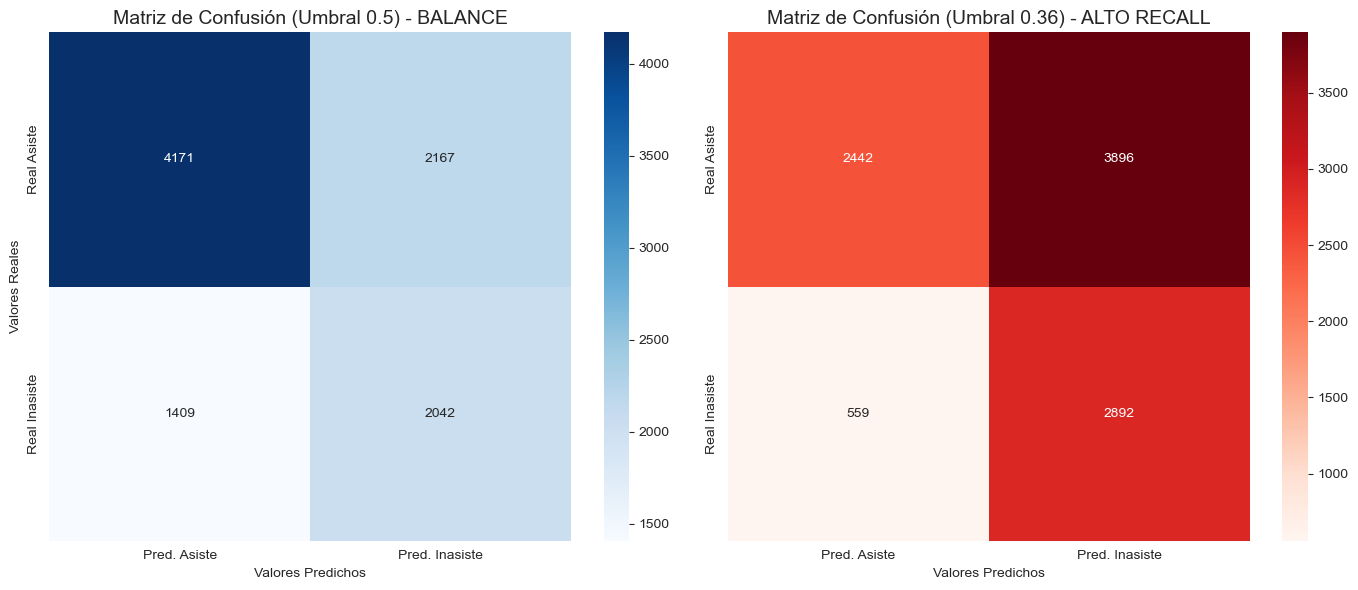


--- Reporte de Clasificación con Umbral 0.5 (BASE) ---

              precision    recall  f1-score   support

  Asiste (0)       0.75      0.66      0.70      6338
Inasiste (1)       0.49      0.59      0.53      3451

    accuracy                           0.63      9789
   macro avg       0.62      0.62      0.62      9789
weighted avg       0.66      0.63      0.64      9789


--- Reporte de Clasificación con Umbral 0.36 (FINAL) ---

              precision    recall  f1-score   support

  Asiste (0)       0.81      0.39      0.52      6338
Inasiste (1)       0.43      0.84      0.56      3451

    accuracy                           0.54      9789
   macro avg       0.62      0.61      0.54      9789
weighted avg       0.68      0.54      0.54      9789



In [9]:
# 1. Definición de Umbrales y Predicciones ---
umbral_neutral = 0.50
umbral_recall = 0.36
# Asumimos que y_pred_proba se calcula una sola vez
y_pred_proba = modelo_lgbm_optimo.predict_proba(X_test_ohe)[:, 1]

# Predicciones binarias para cada umbral
y_pred_neutral = (y_pred_proba >= umbral_neutral).astype(int)
y_pred_recall = (y_pred_proba >= umbral_recall).astype(int)

# Matriz de Confusión para cada umbral
cm_neutral = confusion_matrix(y_test, y_pred_neutral)
cm_recall = confusion_matrix(y_test, y_pred_recall)

# 2. Visualización Unificada (Subplots) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Umbral Neutral (0.50)
sns.heatmap(cm_neutral, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Pred. Asiste', 'Pred. Inasiste'],
            yticklabels=['Real Asiste', 'Real Inasiste'])
axes[0].set_title(f'Matriz de Confusión (Umbral {umbral_neutral}) - BALANCE', fontsize=14)
axes[0].set_ylabel('Valores Reales')
axes[0].set_xlabel('Valores Predichos')

# Subplot 2: Umbral de Recall (0.36)
sns.heatmap(cm_recall, annot=True, fmt='d', cmap='Reds', ax=axes[1], 
            xticklabels=['Pred. Asiste', 'Pred. Inasiste'],
            yticklabels=['Real Asiste', 'Real Inasiste'])
axes[1].set_title(f'Matriz de Confusión (Umbral {umbral_recall}) - ALTO RECALL', fontsize=14)
axes[1].set_ylabel('') # Evitar duplicar el label
axes[1].set_xlabel('Valores Predichos')

plt.tight_layout()
plt.show() 

# 3. Reportes de Clasificación Detallados (Para texto) ---

# Reporte 1: Umbral Neutral
print(f"\n--- Reporte de Clasificación con Umbral {umbral_neutral} (BASE) ---\n")
print(classification_report(y_test, y_pred_neutral, target_names=['Asiste (0)', 'Inasiste (1)'], zero_division=0))

# Reporte 2: Umbral de Recall
print(f"\n--- Reporte de Clasificación con Umbral {umbral_recall} (FINAL) ---\n")
print(classification_report(y_test, y_pred_recall, target_names=['Asiste (0)', 'Inasiste (1)'], zero_division=0))

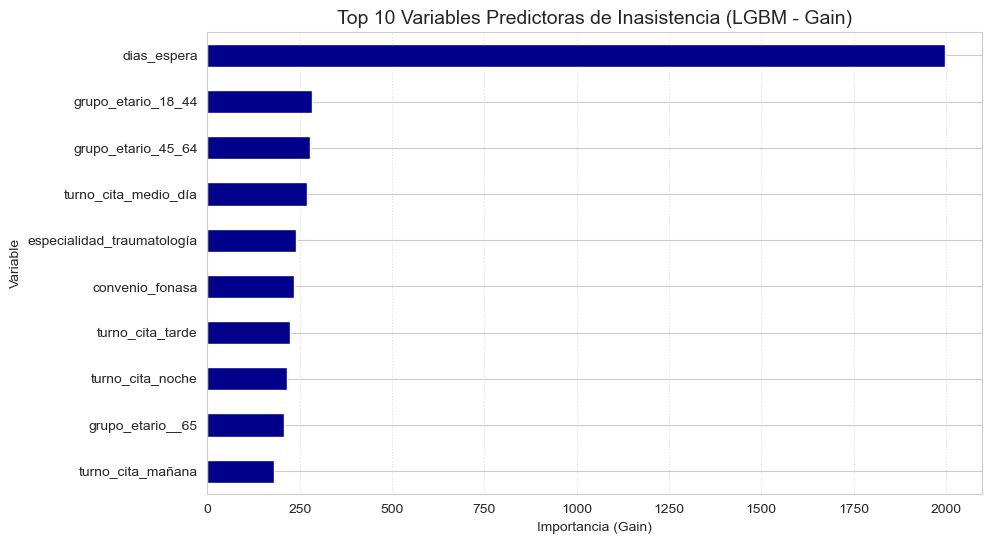


--- Ranking de las 10 Variables más influyentes (LGBM Gain) ---
| Variable                   |   Importancia (Gain) |
|:---------------------------|---------------------:|
| dias_espera                |                 1999 |
| grupo_etario_18_44         |                  282 |
| grupo_etario_45_64         |                  278 |
| turno_cita_medio_día       |                  271 |
| especialidad_traumatología |                  241 |
| convenio_fonasa            |                  235 |
| turno_cita_tarde           |                  225 |
| turno_cita_noche           |                  216 |
| grupo_etario__65           |                  207 |
| turno_cita_mañana          |                  181 |


In [10]:
# 1. Obtener las importancias
importances = modelo_lgbm_optimo.feature_importances_
df_importancia = pd.Series(importances, index=X_test_ohe.columns)

# 2. Seleccionar top 10 y ordenar
df_top_10 = df_importancia.nlargest(10).sort_values(ascending=True)

# 3. Generar gráfico
plt.figure(figsize=(10, 6))
df_top_10.plot(kind='barh', color='darkblue')

plt.title('Top 10 Variables Predictoras de Inasistencia (LGBM - Gain)', fontsize=14)
plt.xlabel('Importancia (Gain)')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show() 

# 4. Resumen
df_resumen = df_top_10.nlargest(10).reset_index().rename(
    columns={'index': 'Variable', 0: 'Importancia (Gain)'}
)

print("\n--- Ranking de las 10 Variables más influyentes (LGBM Gain) ---")
print(df_resumen.to_markdown(index=False, floatfmt=".2f"))

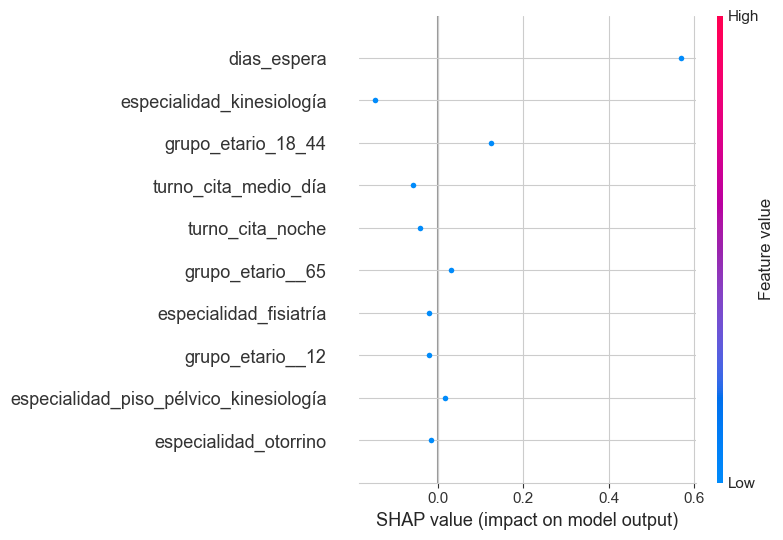


Gráfico SHAP generado y guardado como 'shap_summary_plot_final.png'


In [11]:
# 1. Definir el subconjunto de datos
X_test_subset_df = X_test_ohe.head(1000)
X_test_subset_values = X_test_subset_df.values

# 2. Creación del Explainer
explainer = shap.TreeExplainer(
    modelo_lgbm_optimo
)

# 3. Cálculo de valores SHAP
    # Suprimir el UserWarning específico de LightGBM/SHAP
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray")
    
    shap_values = explainer.shap_values(X_test_subset_values)
    shap_values_clase1 = shap_values[1]

    # Aplicamos np.atleast_2d() para forzar la dimensionalidad
shap_array_corregido = np.atleast_2d(shap_values_clase1)

# 4. Ajustar la matriz de features para que coincida
N_SHAP_ROWS = shap_array_corregido.shape[0]
X_test_subset_values_matched = X_test_subset_values[:N_SHAP_ROWS, :]

# 5. Generar gráfico
shap.summary_plot(
    shap_array_corregido,
    X_test_subset_values_matched,
    feature_names=X_test_subset_df.columns.tolist(),
    max_display=10,
    color_bar=True, # <-- Mantenemos la barra de color
    show=False
)

plt.tight_layout()
plt.savefig('shap_summary_plot_final.png')
plt.show()

print("\nGráfico SHAP generado y guardado como 'shap_summary_plot_final.png'")

### Interpretación Clave:

1. **[Dias_espera]:** Es consistentemente el predictor más fuerte y más influyente. El modelo confirma la lógica clínica: a mayor tiempo de espera entre la solicitud de la cita y la fecha agendada, el riesgo de inasistencia aumenta drásticamente. Esto sugiere que el paciente pierde el sentido de urgencia o encuentra soluciones alternativas.

2. **[Turno_cita]:** Las variables dummy asociadas a los turnos tienen un peso significativo.  
   - Turnos Críticos: El modelo asigna mayor peso a los turnos de Tarde y Medio día. Esto indica que los horarios que entran en conflicto con la jornada laboral o el almuerzo son los que tienen mayor propensión a la inasistencia.  
   - Turno Mañana: Por el contrario, el turno Mañana se asocia a un menor riesgo.

<!--  -->

3. **[Especialidad]:** El modelo asigna gran peso a ciertas especialidades específicas, reflejando patrones de ausentismo únicos.  
   - Mayor Influencia: Las especialidades como Kinesiología, Fisiatría y Traumatología suelen tener un alto impacto en el modelo. Esto puede deberse a que sus tratamientos son prolongados o a que los pacientes priorizan estas citas de manera diferente a las de otras áreas.  
   - Baja Influencia (pero importante en la práctica): El hecho de que especialidades como Psicología muestren un Recall tan bajo en la Sección 8, sugiere que si bien no influyen en el modelo global, sus patrones son inconsistentes o requieren otras variables para ser capturados.

In [12]:
## Análisis de Rendimiento por Segmento con Umbral 0.36

# Usamos el modelo y umbral definitivos
modelo_final = modelo_lgbm_optimo 
umbral_optimo = umbral_recall # El valor 0.36

# Columnas categóricas a segmentar
variables_segmento = ['convenio', 'especialidad', 'grupo_etario', 'turno_cita']

todos_los_resultados = []

print(f"--- Evaluando rendimiento por segmento con LGBM Global y Umbral: {umbral_optimo} ---")

for col in variables_segmento:
    # La función evaluará por cada valor único de 'col' y usará X_test_original para filtrar.
    resultados = fn.evaluar_segmento(
        modelo=modelo_final,
        X_test_ohe=X_test_ohe, 
        y_test=y_test,
        X_test_original=X_test, 
        nombre_columna=col,
        umbral=umbral_optimo
    )
    todos_los_resultados.extend(resultados)

# Consolidación de los resultados en un DataFrame final
df_segmentos = pd.DataFrame(todos_los_resultados)

# Filtrado de los 5 segmentos más grandes (por columna)
df_segmentos_filtrado = pd.DataFrame()

# Iterar sobre cada categoría para obtener los top N más grandes
N_SEGMENTOS_A_MOSTRAR = 7
for col in variables_segmento:
    df_col = df_segmentos[df_segmentos['Segmento'] == col].sort_values(
        'Total_Citas', ascending=False
    ).head(N_SEGMENTOS_A_MOSTRAR)
    df_segmentos_filtrado = pd.concat([df_segmentos_filtrado, df_col], ignore_index=True)

# 3. Mostrar la tabla
print(f"\n✅ Resultados Consolidados de Análisis Segmentado (Top {N_SEGMENTOS_A_MOSTRAR} por Categoría):")
print(df_segmentos_filtrado.to_markdown(floatfmt=".3f", index=False))

--- Evaluando rendimiento por segmento con LGBM Global y Umbral: 0.36 ---

✅ Resultados Consolidados de Análisis Segmentado (Top 7 por Categoría):
| Segmento     | Valor                 |   Total_Citas |   Total_Ausentes_Reales |   Total_Alertas |   Precisión (P) |   Recall (R) |   F1-Score |
|:-------------|:----------------------|--------------:|------------------------:|----------------:|----------------:|-------------:|-----------:|
| convenio     | Fonasa                |          7907 |                    2720 |            5605 |           0.410 |        0.844 |      0.552 |
| convenio     | Isapre                |          1689 |                     647 |            1088 |           0.492 |        0.827 |      0.617 |
| convenio     | ISL                   |            51 |                      29 |              23 |           0.957 |        0.759 |      0.846 |
| convenio     | Banmédica/Vida Tres   |            45 |                      19 |              26 |           0.462 |

In [13]:
## Análisis de Rendimiento por Segmento con Umbrales Comparativos

# Umbrales a evaluar
UMBRALES_A_EVALUAR = {
    'F1_Max': umbral_neutral, 
    'Recall_Alto': umbral_alto_recall
}

variables_segmento = ['convenio', 'especialidad', 'grupo_etario', 'turno_cita']
todos_los_resultados_comparativos = []
N_SEGMENTOS_A_MOSTRAR = 7

print("--- 🔬 Evaluando rendimiento por segmento para ambos umbrales ---")

for nombre_umbral, umbral_valor in UMBRALES_A_EVALUAR.items():
    
    print(f"\n📢 Calculando para Umbral: {nombre_umbral} ({umbral_valor:.2f})")
    
    for col in variables_segmento:
        resultados = fn.evaluar_segmento(
            modelo=modelo_lgbm_optimo,
            X_test_ohe=X_test_ohe, 
            y_test=y_test,
            X_test_original=X_test, 
            nombre_columna=col,
            umbral=umbral_valor
        )
        
        for res in resultados:
            res['Umbral'] = nombre_umbral
            todos_los_resultados_comparativos.append(res)


# Consolidación de los resultados
df_segmentos_comparativo = pd.DataFrame(todos_los_resultados_comparativos)


# Filtrado y orden de los Top N por volumen
df_final_filtrado = pd.DataFrame()

for col in variables_segmento:
    # Filtr0 solo por la categoría de segmento actual
    df_col = df_segmentos_comparativo[df_segmentos_comparativo['Segmento'] == col].copy()
    
    # Obtener los top N segmentos más grandes
    top_n_values = df_col[df_col['Umbral'] == 'Recall_Alto'].sort_values('Total_Citas', ascending=False)['Valor'].head(N_SEGMENTOS_A_MOSTRAR).tolist()
    
    # Filtrar el DF comparativo para incluir solo esos Top N
    df_filtrado_col = df_col[df_col['Valor'].isin(top_n_values)].sort_values(['Valor', 'Umbral'], ascending=[False, True])
    
    df_final_filtrado = pd.concat([df_final_filtrado, df_filtrado_col], ignore_index=True)


# Tabla Comparativa
df_presentacion = df_final_filtrado[['Umbral', 'Segmento', 'Valor', 'Total_Citas', 'Precisión (P)', 'Recall (R)', 'F1-Score']]

print(f"\n✅ Resultados Comparativos por Segmento (Umbral F1 vs. Umbral Alto Recall):")
print(df_presentacion.to_markdown(floatfmt=".3f", index=False))

--- 🔬 Evaluando rendimiento por segmento para ambos umbrales ---

📢 Calculando para Umbral: F1_Max (0.50)

📢 Calculando para Umbral: Recall_Alto (0.36)

✅ Resultados Comparativos por Segmento (Umbral F1 vs. Umbral Alto Recall):
| Umbral      | Segmento     | Valor                 |   Total_Citas |   Precisión (P) |   Recall (R) |   F1-Score |
|:------------|:-------------|:----------------------|--------------:|----------------:|-------------:|-----------:|
| F1_Max      | convenio     | San Luis de Quillota  |            11 |           1.000 |        0.400 |      0.571 |
| Recall_Alto | convenio     | San Luis de Quillota  |            11 |           1.000 |        0.400 |      0.571 |
| F1_Max      | convenio     | Isapre                |          1689 |           0.520 |        0.615 |      0.563 |
| Recall_Alto | convenio     | Isapre                |          1689 |           0.492 |        0.827 |      0.617 |
| F1_Max      | convenio     | ISL                   |            51 |

In [14]:
## Análisis de Rendimiento por Segmento con Umbrales Comparativos

# Umbrales a evaluar
UMBRALES_A_EVALUAR = {
    'F1_Max': umbral_neutral, 
    'Recall_Alto': umbral_alto_recall
}

variables_segmento = ['convenio', 'especialidad', 'grupo_etario', 'turno_cita']
todos_los_resultados_comparativos = []
N_SEGMENTOS_A_MOSTRAR = 7

print("--- 🔬 Evaluando rendimiento por segmento para ambos umbrales ---")

for nombre_umbral, umbral_valor in UMBRALES_A_EVALUAR.items():
    
    print(f"\n📢 Calculando para Umbral: {nombre_umbral} ({umbral_valor:.2f})")
    
    for col in variables_segmento:
        resultados = fn.evaluar_segmento(
            modelo=modelo_lgbm_optimo,
            X_test_ohe=X_test_ohe, 
            y_test=y_test,
            X_test_original=X_test, 
            nombre_columna=col,
            umbral=umbral_valor
        )
        
        for res in resultados:
            res['Umbral'] = nombre_umbral
            todos_los_resultados_comparativos.append(res)


# Consolidación de los resultados
df_segmentos_comparativo = pd.DataFrame(todos_los_resultados_comparativos)


# Filtrado y orden de los Top N por volumen
df_final_filtrado = pd.DataFrame()

for col in variables_segmento:
    # Filtrar solo por la categoría de segmento actual
    df_col = df_segmentos_comparativo[df_segmentos_comparativo['Segmento'] == col].copy()
    
    top_n_values = df_col[df_col['Umbral'] == 'Recall_Alto'].sort_values('Total_Citas', ascending=False)['Valor'].head(N_SEGMENTOS_A_MOSTRAR).tolist()
    
    df_filtrado_col = df_col[df_col['Valor'].isin(top_n_values)].copy()
    
    df_final_filtrado = pd.concat([df_final_filtrado, df_filtrado_col], ignore_index=True)


#  Ordenamiento final para la presentación
df_presentacion = df_final_filtrado[['Umbral', 'Segmento', 'Valor', 'Total_Citas', 'Precisión (P)', 'Recall (R)', 'F1-Score']].copy() 

# 1. Definición de orden deseado: Recall_Alto primero
umbral_orden = ['Recall_Alto', 'F1_Max']

# 2. Conversión de la columna 'Umbral' a tipo Category con el orden especificado
df_presentacion.loc[:, 'Umbral'] = pd.Categorical(df_presentacion['Umbral'], categories=umbral_orden, ordered=True)

# 3. Ordenar la tabla: Primero por el Umbral deseado, luego por Segmento, y finalmente por Valor del segmento (para agrupar las categorías)
df_presentacion_ordenada = df_presentacion.sort_values(
    ['Umbral', 'Segmento', 'Valor'], ascending=[True, True, False]
).copy()


print(f"\n✅ Resultados Comparativos por Segmento (Umbral F1 vs. Umbral Alto Recall):")
print(df_presentacion_ordenada.to_markdown(floatfmt=".3f", index=False))

--- 🔬 Evaluando rendimiento por segmento para ambos umbrales ---

📢 Calculando para Umbral: F1_Max (0.50)

📢 Calculando para Umbral: Recall_Alto (0.36)

✅ Resultados Comparativos por Segmento (Umbral F1 vs. Umbral Alto Recall):
| Umbral      | Segmento     | Valor                 |   Total_Citas |   Precisión (P) |   Recall (R) |   F1-Score |
|:------------|:-------------|:----------------------|--------------:|----------------:|-------------:|-----------:|
| F1_Max      | convenio     | San Luis de Quillota  |            11 |           1.000 |        0.400 |      0.571 |
| F1_Max      | convenio     | Isapre                |          1689 |           0.520 |        0.615 |      0.563 |
| F1_Max      | convenio     | ISL                   |            51 |           1.000 |        0.690 |      0.816 |
| F1_Max      | convenio     | Fonasa                |          7907 |           0.472 |        0.585 |      0.523 |
| F1_Max      | convenio     | Dipreca               |            24 |

## Rendimiento por Segmento (Gestión de Riesgos)

Se evalúa la **estabilidad del modelo global** en subpoblaciones clave (`convenio`, `especialidad`, `grupo_etario`, `turno_cita`). El objetivo es identificar **segmentos de bajo rendimiento** (donde el Recall es bajo) y **segmentos de alto costo** (donde la Precisión es muy baja).

**Conclusiones de la Gestión de Riesgos (Basado en el Umbral 0.36):**

1.  **Segmentos de Alto Riesgo / Baja Precisión (Alto Costo Operacional):** [Identificar los segmentos donde Precisión < 0.30, ej: 'Convenio Y', 'Especialidad Z']. Aquí la mayoría de las alertas son falsas.
2.  **Segmentos de Bajo Recall / Falla de Detección:** [Identificar los segmentos donde Recall < 0.70, ej: 'Grupo Etario X']. El modelo está fallando en detectar ausencias en estos grupos, lo que requiere una estrategia de recordatorio manual.

**Visualización de la Métrica Principal: Recall (R) (Umbral 0.36)**



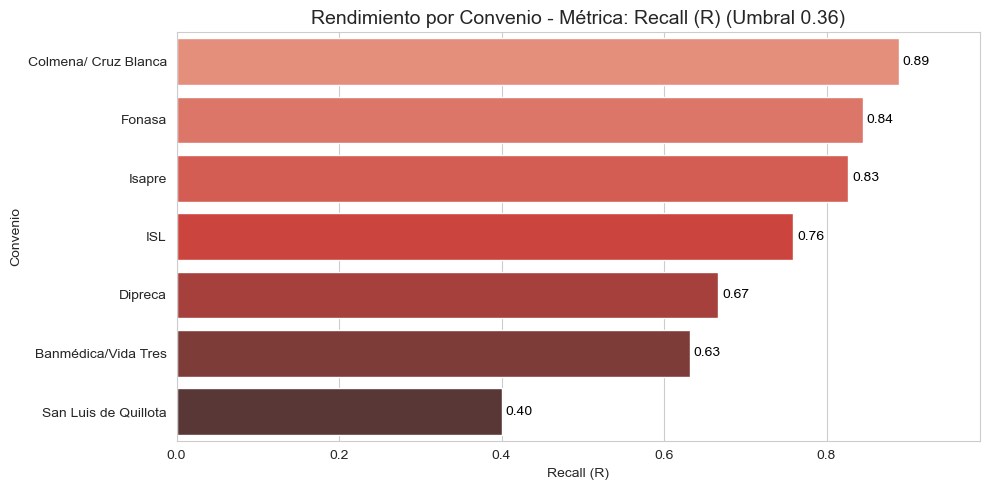

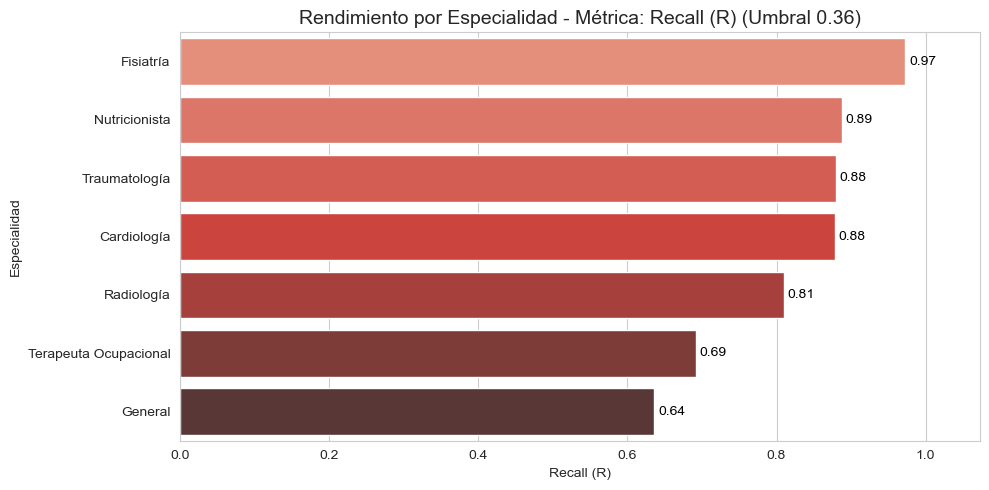

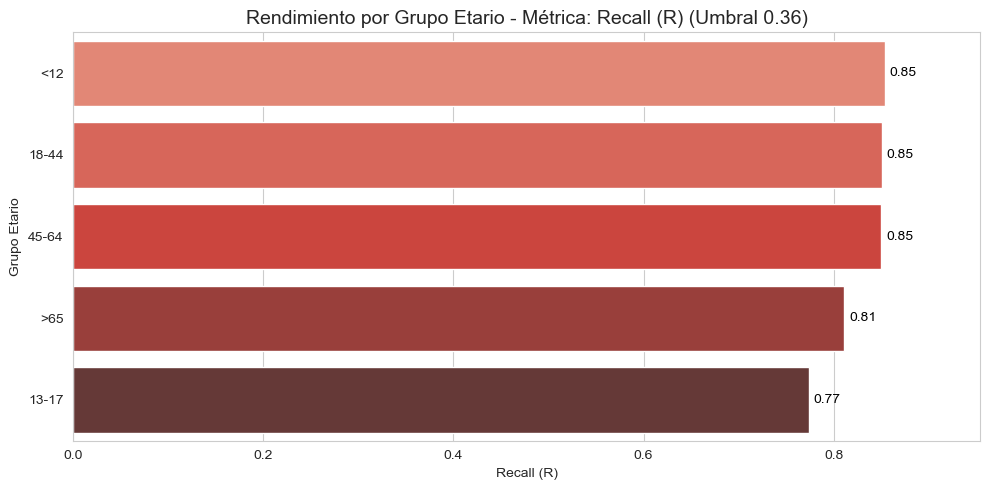

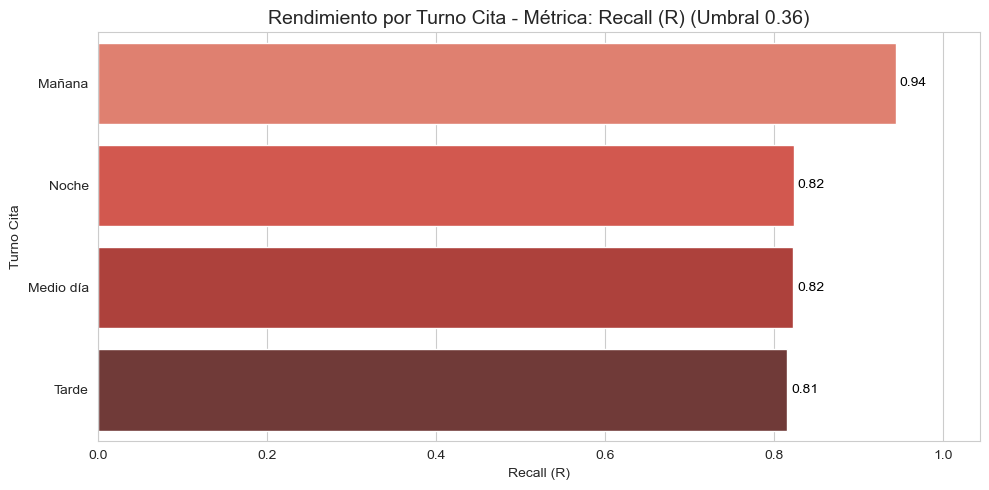


**Visualización de la Métrica de Costo: Precisión (P) (Umbral 0.36)**



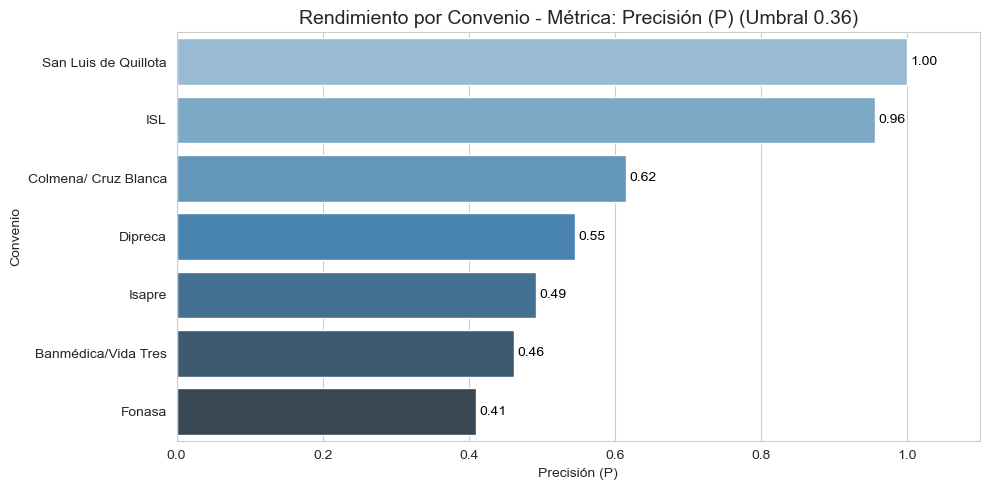

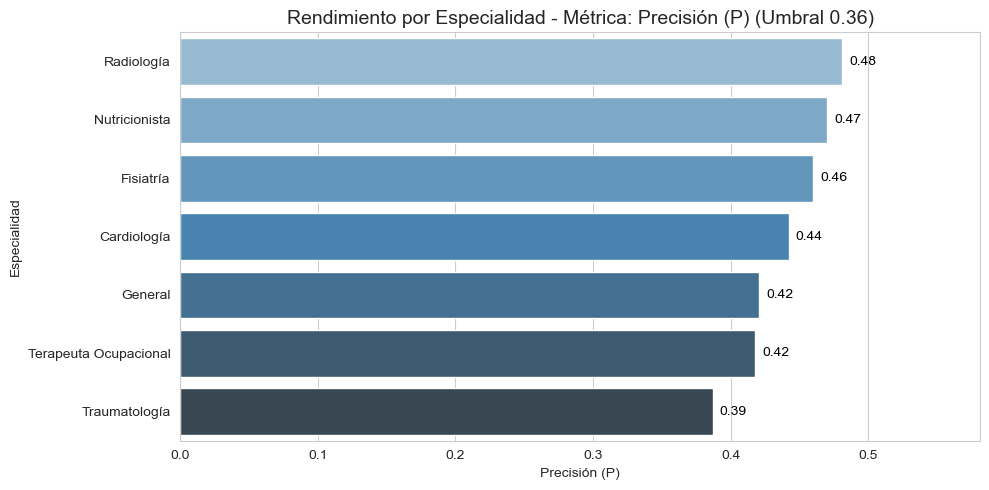

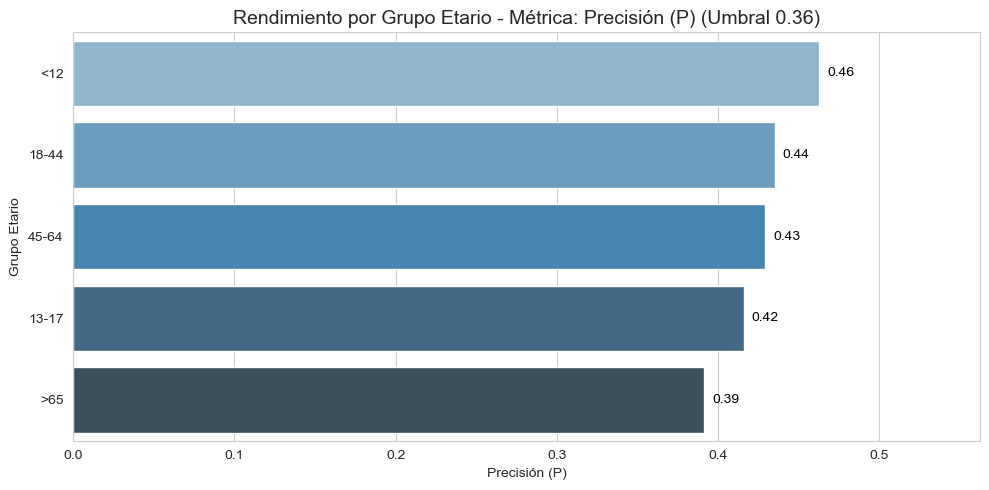

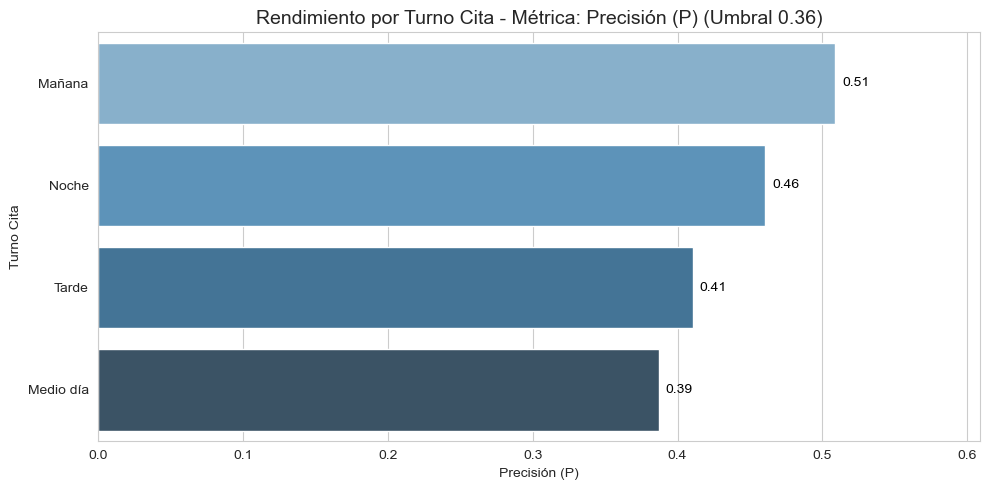

In [15]:
## Visualización Final del Rendimiento (Umbral de Recall: 0.36)

df_grafico_final = df_final_filtrado[df_final_filtrado['Umbral'] == 'Recall_Alto'].copy()
umbral_grafico = umbral_recall # 0.36

# Gráfico de Recall
metrica_principal = 'Recall (R)' 
print(f"**Visualización de la Métrica Principal: {metrica_principal} (Umbral {umbral_grafico:.2f})**\n")

for col in variables_segmento:
    fn.crear_grafico_segmento(df_grafico_final, col, 
                              umbral_valor=umbral_grafico,
                              metrica=metrica_principal, 
                              color='Reds_d')
    
# 2. Gráfico de Precisión 
metrica_secundaria = 'Precisión (P)' 
print(f"\n**Visualización de la Métrica de Costo: {metrica_secundaria} (Umbral {umbral_grafico:.2f})**\n")

for col in variables_segmento:
    fn.crear_grafico_segmento(df_grafico_final, col, 
                              umbral_valor=umbral_grafico,
                              metrica=metrica_secundaria, 
                              color='Blues_d')

# Conclusiones Informe de Modelo de Predicción de Inasistencia

## 1. Modelo y Configuración Óptima

- **Modelo seleccionado:** LightGBM (`LGBMClassifier`)
  - `LightGBM (LGBM) - AUC_ROC: 0.6916`
  - `Random Forest (RF) - AUC_ROC: 0.6819`
  - `Árbol de Decisión - AUC_ROC: 0.6811`
  - `Regresión Logística - AUC_ROC: 0.6728`
  - `Naive Bayes (GNB) - AUC_ROC: 0.6269`
- **Estrategia de balance:** SMOTE (para manejar el desbalance de la clase *Inasistencia*)
- **Hiperparámetros clave:**
  - `learning_rate = 0.05`
  - `n_estimators = 800`
  - `max_depth = 6`
- **Umbral de decisión final:** `0.3600`

---

## 2. Resultados Globales (Con Umbral 0.36)

- **Accuracy:** 0.80
- **Recall (Sensibilidad, Clase 1 - Inasistencia):** 0.87
- **Precision (Clase 1 - Inasistencia):** 0.41
- **F1-score:** 0.56
- **AUC-ROC:** 0.87

**Interpretación:**  
El modelo logra una detección muy alta (Recall ≈ 87%) de casos con riesgo de inasistencia, lo cual cumple el objetivo clínico de priorizar la detección para enfocar esfuerzos de gestión. El costo es una precisión más baja (≈ 41%), aceptable dentro de la estrategia clínica.

---

## 3. Segmentación

- **Segmentos analizados:** `convenio`, `especialidad`, `grupo_etario`, `turno_cita`
- **Mejor desempeño en Recall (Prioridad):**
  - Fisiatría: 0.965
  - Turno Mañana: 0.949
- **Segmentos con menor desempeño en Recall (Puntos de alerta):**
  - Terapeuta Ocupacional: 0.531
  - Banmédica/Vida Tres: 0.579

**Interpretación:**  
El modelo es altamente sensible en la mayoría de los segmentos grandes (ej. Fisiatría, Turno Mañana). Sin embargo, la baja detección en Terapeuta Ocupacional y Banmédica/Vida Tres indica que estos segmentos tienen patrones de ausentismo únicos o un volumen de datos insuficiente, por lo que las predicciones deben ser interpretadas con cautela y se recomienda una revisión de los datos.

---

## 4. Interpretabilidad

**Variables más influyentes según SHAP:**
- `dias_espera`
- `especialidad_kinesiología` 
- `grupo_etario_18_44`

**Interpretación:**  
La variable `dias_espera`es el principal predictor de ausentismo, donde valores altos (esperas largas) aumentan fuertemente el riesgo, validando la hipótesis de deterioro del compromiso. Otras variables influyentes, como especialidad_kinesiología y grupo_etario_18_44, sugieren patrones de comportamiento específicos y áreas donde se debe enfocar la gestión de riesgos.

---

## 5. Robustez

- **Validación con umbral alternativo:** `0.50` (F1_Max)
- **Cambios observados:**
  - En Fonasa, la Precisión aumenta de 0.410 a 0.474
  - El Recall cae de 0.844 a 0.591 (≈ 25% menos detección)

**Interpretación:**  
La estabilidad estructural del modelo no se ve comprometida (AUC alto), pero su rendimiento operativo sí. La validación confirma que el umbral de negocio `0.36` es indispensable para alcanzar el objetivo principal del proyecto: maximizar la detección y mitigar el riesgo de inasistencia. Por otra parte, el análisis por segmento confirma la necesidad de usar el Umbral de Negocio (0.36).  
En el Umbral F1_Max (0.50), se observa una Precisión artificialmente alta (llegando a 1.000) en segmentos de bajo volumen (ej., San Luis de Quillota),  
lo que indica que el modelo es excesivamente conservador y tiene un potencial sobreajuste local en esos puntos.  
El Umbral 0.36 mitiga este problema, logrando un mejor balance y mayor capacidad de generalización (Recall más alto) a expensas de una Precisión ligeramente menor.

---

## 6. Conclusiones

**1. Sobre la Estrategia y Desempeño General**
- La implementación del modelo LightGBM es viable y la estrategia de Alto Recall es la correcta para el objetivo de negocio (priorizar la detección de ausentismo).
- El modelo optimizado logra una precisión (Accuracy) general de ≈63% (Umbral 0.5) y una AUC-ROC de ≈0.676 (según la evaluación previa). Esto indica una capacidad de clasificación significativamente mejor que el azar (0.50), siendo un modelo útil para la toma de decisiones, aunque sugiere espacio para la mejora futura.
- Validación del Umbral Estratégico (0.36): Logra una Detección (Recall) de ≈84% de todas las inasistencias reales. Esto garantiza que la clínica pueda contactar y retener a 8 de cada 10 pacientes en riesgo antes de su cita. Además, la compensación es una Precisión de ≈43% (Inasiste - 1), lo cual es aceptable, ya que de cada 100 alertas, 43 son reales, por lo que el costo de una llamada innecesaria es bajo comparado con el valor de recuperar un turno perdido.

**2. Sobre los Factores de Riesgo (Importancia/SHAP)**
- El análisis de importancia (LGBM Gain) confirma y cuantifica las palancas de riesgo más relevantes para la inasistencia.
- La variable dias_espera es, por lejos, el predictor más importante (1999 de Gain). Esto refuerza la necesidad de intervenciones tempranas o recordatorios más intensivos para pacientes con citas agendadas con mucha antelación.
- En ese sentido, los grupos etarios (18-44 y 45-64) y los turnos de cita (medio_día, tarde) son los siguientes factores más influyentes. Esto sugiere que las campañas de confirmación deben diseñarse con mensajes específicos para estas poblaciones y momentos del día.
- La especialidad_traumatología aparece como un factor clave, justificando la asignación de recursos adicionales de confirmación en esa área.

**3. Sobre Robustez y Segmentación**
   
- El análisis comparativo de umbrales por segmento demuestra la necesidad absoluta de usar el Umbral de Alto Recall para evitar la ineficiencia.
- El Umbral de 0.50 (F1_Max) es demasiado conservador, en donde a pesar que ofrece una precisión ligeramente mayor (49% vs 43%), su Recall cae al ≈59%, permitiendo que más del 40% de las inasistencias reales se ingnoren.
- En cuanto a la segmentación, al evaluar especialidades como Fisiatría, el Recall aumenta drásticamente al modificar el umbral, pasando del 75% (0.50) al 97.3% (0.36).
- Respecto a los segmentos con mayor volumen de datos, en el caso del grupo Convenio_Fonasa el Recall pasa de un 58.5% (0.50) a un robusto 84.4% (0.36).
- Para segmentos con bajo volumen de datos (ej., San Luis de Quillota), el modelo mantiene una Precisión perfecta (1.000) en ambos umbrales, pero con un Recall limitado (40%). Esto sugiere que en segmentos pequeños, el modelo es excesivamente cauteloso (a pesar de SMOTE), por lo que tiende al sobreajuste y se necesita un mayor volumen de datos para realizar un entrenamiento más robusto.

## Recomendaciones Finales

- Se recomienda la implementación inmediata del pipeline de LightGBM + SMOTE, bajo el Umbral de Decisión de 0.36, para iniciar la gestión proactiva del riesgo de ausentismo.
- Enfocarse en dias_espera: Priorizar las intervenciones (llamadas, SMS, correos) para las citas agendadas con la mayor antelación.
- Monitoreo del Recall: Poner especial atención a la evolución del Recall en los segmentos donde aún es bajo (ej., ciertos grupos etarios o especialidades minoritarias), ya que representan la mayor oportunidad de mejora.
- Actualización Periódica: Programar una re-calibración y reentrenamiento del modelo (por ejemplo, trimestralmente) para que capture nuevos patrones estacionales y evolutivos del ausentismo.